# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [202]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [203]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv("/datasets/users_latam.csv")
usage = pd.read_csv("/datasets/usage.csv")

In [204]:
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [205]:
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [206]:
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [207]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [208]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [209]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [210]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [211]:
# cantidad de nulos para users
print(plans.isna().sum())
print(plans.isna().mean())

plan_name            0
messages_included    0
gb_per_month         0
minutes_included     0
usd_monthly_pay      0
usd_per_gb           0
usd_per_message      0
usd_per_minute       0
dtype: int64
plan_name            0.0
messages_included    0.0
gb_per_month         0.0
minutes_included     0.0
usd_monthly_pay      0.0
usd_per_gb           0.0
usd_per_message      0.0
usd_per_minute       0.0
dtype: float64


In [212]:
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: 
 Dataset plans: no se tiene valores nulos
 Dataset usage: se tiene valores nulos en las columnas duration con un 55.19% y length con 44.74% de valores nulos se hara una investigacion para saber si es un dato que que pueda afectar nuestro analisis 

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
**- ¿Qué columnas tienen valores faltantes y en qué proporción?**
- usage:
      date con 50 datos nulos y en proporcion 0.125%
      duration: con 22076 datos nulos en proporcion del 55.19%
      length: con 17896 con una proporcion del 44.74%
**- Indica qué harías: ¿imputar, eliminar, ignorar?**
- Investigar si son datos que puedan influenciar en el analisis pero si hay algunos que pudieran imputarse posiblemente duration se podria sacar una media para imputar. 

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [213]:
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` es solo un identificador  asi que sus estadisticas no tienen mucho significado real.
- La columna `age` hay 4000 registros de edad con un promedio de 34 años pero en la std se tiene un foco rojo ya que arroja 123 siendo un numero muy alto esto puede implicar que se tienen sentinels.  

In [214]:
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` no se tienen mucha importancia ya que solo son identificadores.
- Las columnas `duartion` se tienen 17,924 de 40,000 indicando que hay muchos valores faltantes posiblemente no todas sean llamadas, se tiene un promedio de 5:20min, la std es de 6:64 lo cual se tiene una dispersion basatante alta comparada con la media lo que suguiere gran variedad en las duraciones, en el minimo se tiene 0 podria ser una llamada perdida y en los porcentajes 25% = 1.44, 50%= 3.5, 75%= 6.99 deliverando que la  mayoria de las llamadas son cortas menores a 7 min, en el valor max muestra 120 min dos horas aunque sea un valor bastante alto es posible. En la columna de `length` muestra un conteo de 22,104 de 40,000 mostrando valores faltantes, con un promedio de 52.13 interpretando que los mensajes tienen 52 caracteres, en cuanto a su std se tiene una dispersion un poco alta en respecto a la media con 56.61, hay un minimo de 0 que podrian ser mensajes vacios enviados y un maximo de 1490 caracteres que es considerable alto comparado con el resto.

In [215]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe


<bound method NDFrame.describe of           city     plan
0     Medellín   Basico
1            ?   Basico
2         CDMX   Basico
3       Bogotá  Premium
4          GDL   Basico
...        ...      ...
3995  Medellín   Basico
3996  Medellín  Premium
3997    Bogotá  Premium
3998    Bogotá   Basico
3999    Bogotá   Basico

[4000 rows x 2 columns]>

- La columna `city` se tiene "?" como un valor desconocido para estandarizar mejor la informacion se debe cambiar por una palabra que identifique que desconoce la informacion de ese dato.
- La columna `plan` no se encontraron anomalias 

In [216]:
# explorar columna categórica de usage
usage['type'].describe

<bound method NDFrame.describe of 0        call
1        text
2        text
3        call
4        call
         ... 
39995    call
39996    call
39997    call
39998    text
39999    call
Name: type, Length: 40000, dtype: object>

- La columna `type` se tiene que hay dos tipos de datos text y call lo cual explica los datos faltantes en las columnas de duration y length. 

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
**- ¿En qué columnas encontraste valores inválidos o sentinels?** 
Dataset users: columna `age` hay sentinels valores de -999 
            En las columnas `city` se encontraron valores invalidos "?"
Dataset usage: columnas `length`y `duration` tiene valores faltantes debido a que su columma `type` maneja dos tipos de valores de texto y de tipo call(llamada)            
   
- ¿Qué acción tomarías?
  para los sentinels imputar la media ya que se trata de la edad se puede ver si trabajando con la mediana se puede sustituir esos valores, para los valores invalidos como en el caso de ciudad que tenemos "?" cambiar a "unknown". Para el caso de los valores faltantes separa quizas las columnas de `type`para separa las llamadas de los textos. 

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [144]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users["reg_date"]).dt.year

In [145]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage["date"], format= "%Y/%m/%d")

In [146]:
# Revisar los años presentes en `reg_date` de users
users["reg_date"].value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date` que existen datos del 2026 que no se van utilizar en el analisis ya que tomaremos la informacion hasta el 2024 y se tomara los datos del dt usage.

In [147]:
# Revisar los años presentes en `date` de usage
usage["date"].dt.year
usage["date"].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date` se muestran 39950 registros en el año 2024
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
**- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)** Dentro de `reg_date` se encuentran fechas desde el 2022 hasta el 2024 pero unicamente estan como registro de linea, mientras que en `date` se encuentran 39960 registros que nos podria ayudar a obtener mas datos o tendencias.
- ¿Qué harías con ellas? trabajar sobre las fechas de usage y  en las de users seria solo utilizar las fechas de 2024.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [217]:
# Reemplazar -999 por la mediana de age
age_no_valid= users[users["age"] == -999]["age"].count()
print(age_no_valid)

age_mediana = users[users["age"] != -999]["age"].median()
users['age'] = users["age"].replace(-999, age_mediana)


# Verificar cambios
users['age'].describe()

55


count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [149]:
# Reemplazar ? por NA en city
users["city"]= users["city"].replace("?","NA")


# Verificar cambios
users["city"].describe()

count       3531
unique         7
top       Bogotá
freq         808
Name: city, dtype: object

In [150]:
# Marcar fechas futuras como NA para reg_date
users["reg_date"]= users["reg_date"].replace(["2026"], pd.NA)

# Verificar cambios
users.describe

<bound method NDFrame.describe of       user_id first_name last_name   age      city  reg_date     plan  \
0       10000     Carlos    Garcia  38.0  Medellín      2022   Basico   
1       10001      Mateo    Torres  53.0        NA      2022   Basico   
2       10002      Sofia   Ramirez  57.0      CDMX      2022   Basico   
3       10003      Mateo   Ramirez  69.0    Bogotá      2022  Premium   
4       10004      Mateo    Torres  63.0       GDL      2022   Basico   
...       ...        ...       ...   ...       ...       ...      ...   
3995    13995        Ana     Lopez  60.0  Medellín      2024   Basico   
3996    13996     Carlos   Ramirez  24.0  Medellín      2024  Premium   
3997    13997        Ana     Lopez  58.0    Bogotá      2024  Premium   
3998    13998    Mariana     Lopez  57.0    Bogotá      2024   Basico   
3999    13999        Ana     Lopez  20.0    Bogotá      2024   Basico   

     churn_date  
0           NaN  
1           NaN  
2           NaN  
3           NaN  

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [151]:
# Verificación MAR en usage (Missing At Random) para duration
usage["duration"].isna().groupby(usage["type"]).mean()

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [152]:
# Verificación MAR en usage (Missing At Random) para length
usage["length"].isna().groupby(usage["type"]).mean()

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` los nulos que se encuentran son porque los que se identifican como text  y `length` los nulos son las llamadas como  `duration` y `length` son columans separadas aparecen en todos los datos.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [153]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = (
    usage.groupby("user_id")
        .agg(
            cant_mensajes= ("is_text", "sum"),
            cant_llamadas=("is_call", "sum"),
            total_minutos_llamada =("duration", "sum"),
        )
        .reset_index()
)

# observar resultado
usage_agg.head()

,user_id,cant_mensajes,cant_llamadas,total_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74
3,10003,11,3,8.99
4,10004,4,3,8.01


In [154]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on = "user_id", how= "left")
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,total_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,NA,2022,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [155]:
# Resumen estadístico de las columnas numéricas
cols_num = ["cant_mensajes", "cant_llamadas","total_minutos_llamada"]
user_profile[cols_num]= user_profile[cols_num].fillna(0)
user_profile.describe()

,user_id,age,reg_date,cant_mensajes,cant_llamadas,total_minutos_llamada
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,11999.500000,48.136000,2023.034000,5.523000,4.477000,23.311225
std,1154.844867,17.689919,0.866044,2.359738,2.145139,18.169564
min,10000.000000,18.000000,2022.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,2022.000000,4.000000,3.000000,11.107500
50%,11999.500000,48.000000,2023.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,2024.000000,7.000000,6.000000,31.412500
max,13999.000000,79.000000,2026.000000,17.000000,15.000000,155.690000


In [156]:
# Distribución porcentual del tipo de plan
distribucion_porcentual_plan= (users["plan"].value_counts(normalize=True)*100).round(2)
print(distribucion_porcentual_plan)

Basico     64.88
Premium    35.12
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

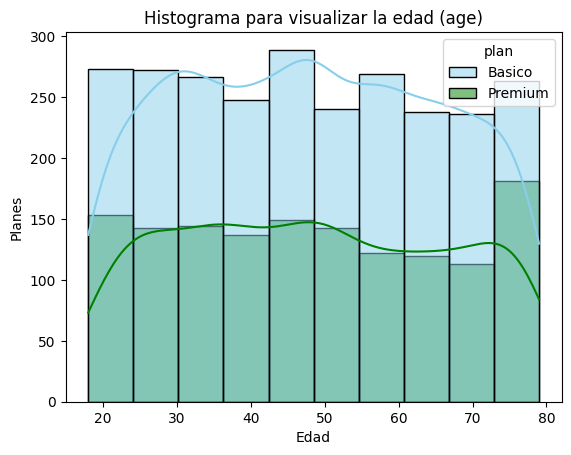

In [157]:
# Histograma para visualizar la edad (age)
sns.histplot(data= user_profile, x= "age", hue= "plan", bins= 10, palette=["skyblue","green"], edgecolor= "black", kde=True) 

plt.xlabel("Edad")
plt.ylabel("Planes")
plt.title("Histograma para visualizar la edad (age)" )
plt.show()

💡Insights: No existe un patron o sesgo por edad en la preferencia de plan; la base de usarios de ambos planes esta distribuida de manera uniforme entre jovenes, adultos y adultos mayores. 
- Distribución uniforme / plana a lo largo de todos los rangos de edad.

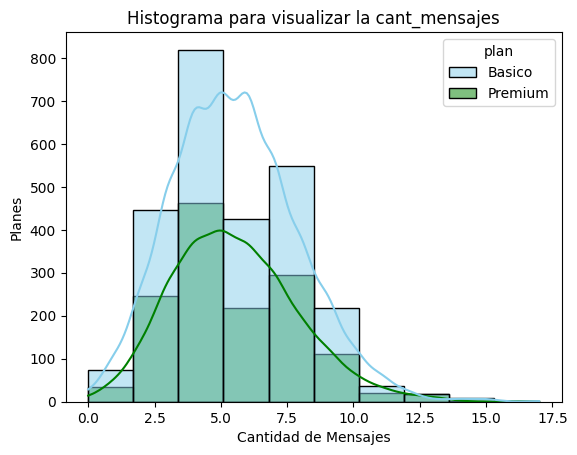

In [158]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data= user_profile, x= "cant_mensajes", hue= "plan", bins= 10, palette=["skyblue","green"], edgecolor= "black", kde=True) 

plt.xlabel("Cantidad de Mensajes")
plt.ylabel("Planes")
plt.title("Histograma para visualizar la cant_mensajes" )
plt.show()

💡Insights: La variable cant_mensajes un sesgo a la derecha, con una concentracion mayormente entre 2 y 8 mensajes por usuario. Aunque el plan Basico cuenta con un volumen mayor de usuarios ambos usuarios (Basico y Premium) muestran un patron de envio similar alcanzando su pico mayor de los 4 a 5 mensajes.
- Muestra una Distribucion sesgada a la derecha (asimetria positiva)

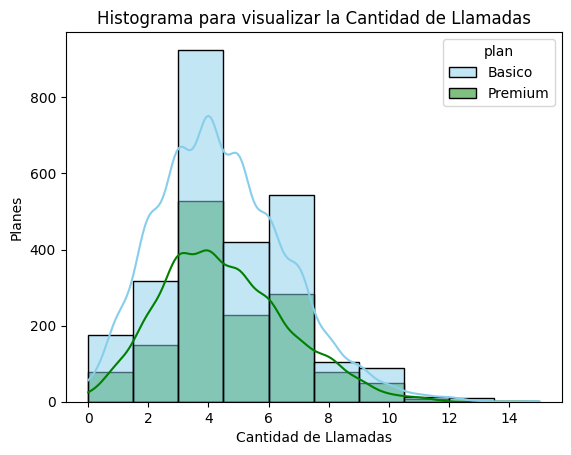

In [159]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data= user_profile, x= "cant_llamadas", hue= "plan", bins= 10, palette=["skyblue","green"], edgecolor= "black", kde=True) 

plt.xlabel("Cantidad de Llamadas")
plt.ylabel("Planes")
plt.title("Histograma para visualizar la Cantidad de Llamadas" )
plt.show()

💡Insights: La variable cant_llamadas presenta una distribución sesgada a la derecha, donde la mayoría de los usuarios realiza entre 3 y 7 llamadas. Respecto al plan, no existe una diferencia drástica en el comportamiento de uso: tanto los usuarios del plan Básico como los del Premium concentran su mayor actividad en el rango de 3 a 4.5 llamadas.
- Distribución Distribución sesgada a la derecha (asimetría positiva): La gran concentración de datos se agrupa en valores moderados (3 a 7 llamadas) y decae de forma progresiva hacia la derecha, formando una "cola" en valores más altos (alrededor de 10 a 14 llamadas).

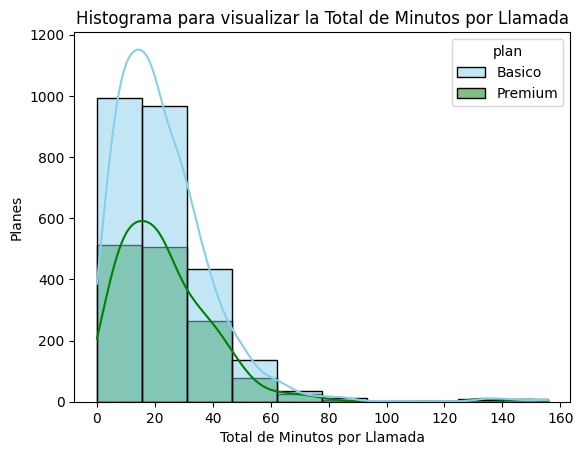

In [160]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data= user_profile, x= "total_minutos_llamada", hue= "plan", bins= 10, palette=["skyblue","green"], edgecolor= "black", kde=True) 

plt.xlabel("Total de Minutos por Llamada")
plt.ylabel("Planes")
plt.title("Histograma para visualizar la Total de Minutos por Llamada" )
plt.show()

💡Insights: La variable de minutos por llamada presenta una distribución sesgada a la derecha, donde la mayoría de los usuarios de ambos planes habla entre 0 y 30 minutos acumulados. Los usuarios de ambos planes (Básico y Premium) siguen una curva de comportamiento muy similar, disminuyendo rápidamente la cantidad de usuarios conforme aumentan los minutos consumidos, salvo por un pequeño grupo marginal con consumos atípicos superiores a los 60 minutos.


### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

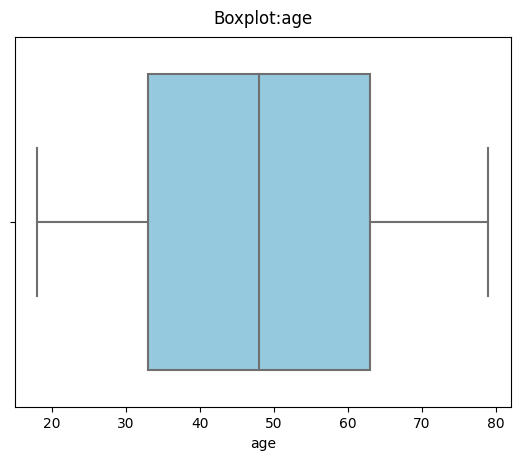

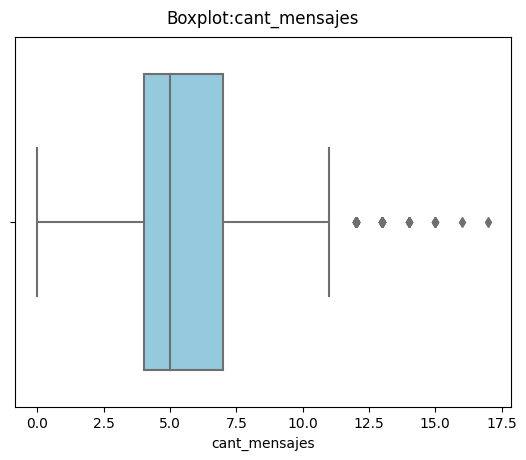

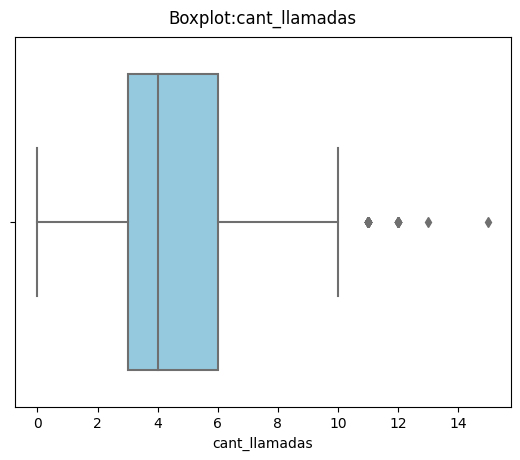

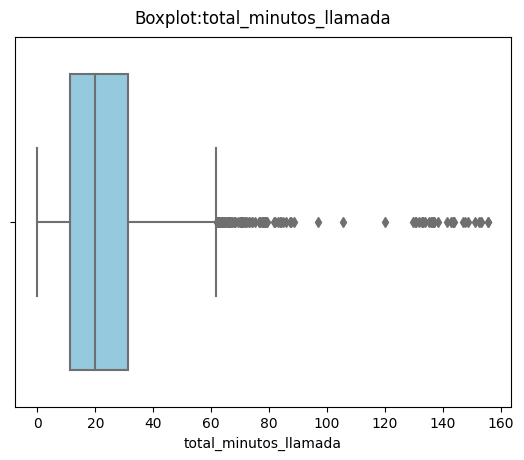

In [161]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'total_minutos_llamada']

for col in columnas_numericas:
    if col in user_profile.columns:
        sns.boxplot(user_profile[col], color= "skyblue")
        plt.title(f'Boxplot:{col}', fontsize=12, pad= 10)
        plt.xlabel(col, fontsize= 10)
        plt.show()

💡Insights: 
- **Age:** No presenta puntos aislados, todos los datos de (presenta o no outliers). La variable age está completamente limpia en cuanto a outliers, por lo que no requiere ningún tipo de recorte, imputación o ajuste por método IQR.
- **cant_mensajes:** Se observan rombos grises ubicados a la derecha del "bigote" superior, desde 12 hasta 17 mensajes aprox. Los valores atípicos se encuentran únicamente en el extremo superior (lado derecho). En el límite inferior no existen outliers, ya que el bigote llega normalmente hasta 0. El $50\%$ central de los datos (la caja) se concentra entre los 4 mensajes ($Q1$) y los 7 mensajes ($Q3$), con una mediana cercana a los 5 mensajes. Como solo hay outliers del lado superior, no es necesario calcular el límite inferior.
- **cant_llamadas:** Sí, se identifican valores atípicos únicamente en el extremo superior (usuarios que realizan de 11 a 15 llamadas).Al igual que con los mensajes, estos puntos representan clientes de consumo intensivo (heavy callers). Se recomienda conservarlos en análisis descriptivos o de segmentación, o aplicar recorte por límite superior en 10.5 (clipping) si los datos van a ser procesados por modelos de regresión o algoritmos sensibles a valores extremos.
- **cant_minutos_llamada:** Existe una gran cantidad de valores atípicos superiores que van desde los 62 minutos hasta aproximadamente los 156 minutos. Al tratarse de consumo de minutos, estos valores reflejan comportamientos reales de uso intensivo. Se recomienda conservarlos en el análisis exploratorio y descriptivo para identificar perfiles de alto valor (heavy users), o bien aplicar una imputación por tope a $61.5$ minutos (winsorization/clipping) si los datos se utilizarán para algoritmos estadísticos o analíticos que puedan verse distorsionados por colas largas. 

In [171]:
# Calcular límites con el método IQR
columnas_limites = ["age","cant_mensajes","cant_llamadas","total_minutos_llamada"]
def calcular_iqr(serie):
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    return pd.Series(
        {
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "Límite_Superior": q3 + 1.5 * iqr,
        }
    )


# Aplicamos la función directamente al subconjunto de columnas
cols_analizar = ["age", "cant_mensajes", "cant_llamadas", "total_minutos_llamada"]
resumen_iqr = (
    user_profile[cols_analizar].apply(calcular_iqr).T.round(2)
)

print(resumen_iqr)

                          Q1     Q3   IQR  Límite_Superior
age                    33.00  63.00  30.0           108.00
cant_mensajes           4.00   7.00   3.0            11.50
cant_llamadas           3.00   6.00   3.0            10.50
total_minutos_llamada  11.11  31.41  20.3            61.87


In [172]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,total_minutos_llamada
count,4000.000000,4000.000000,4000.000000,4000.000000
mean,48.136000,5.523000,4.477000,23.311225
std,17.689919,2.359738,2.145139,18.169564
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.107500
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.412500
max,79.000000,17.000000,15.000000,155.690000


💡Insights: 
- **cant_mensajes: mantener o no outliers, porqué?**  Mantenerlos outliers, refleja heavy users reales; no son errores. Conservarlos permite identificar segmentos de clientes con alto engagement o necesidades particulares para ofertas de planes superiores. 
- **cant_llamadas: mantener o no outliers, porqué?** Mantener outliers, comportamiento legítimo de alta interacción. Si se eliminan los registros, sesgaría la muestra eliminando precisamente a la población que genera mayor tráfico y demanda en la red de llamadas.
- **cant_minutos_llamada: mantener o no outliers, porqué?** Mantener los outliers, los minutos consumidos suelen ser la variable con mayor impacto económico en los planes de telefonía. Eliminar estos casos atípicos ocultaría el comportamiento de los clientes más costosos o de mayor rentabilidad.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [173]:
# Crear columna grupo_uso
def clasificar_uso(row):
    if row["cant_llamadas"] < 5 and row["cant_mensajes"] < 5:
        return "Bajo uso"
    elif row["cant_llamadas"] < 10 and row["cant_mensajes"] < 10:
        return "Uso medio"
    else:
        return "Alto uso"

user_profile["grupo_uso"] = user_profile.apply(clasificar_uso, axis=1)

In [174]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,total_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,NA,2022,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [175]:
# Crear columna grupo_edad
def clasificar_edad(edad):
    if edad < 30:
        return "Joven"
    elif edad < 60:
        return "Adulto"
    else:
        return "Adulto Mayor"
user_profile["grupo_edad"] = user_profile["age"].apply(clasificar_edad)

In [176]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,total_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,NA,2022,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

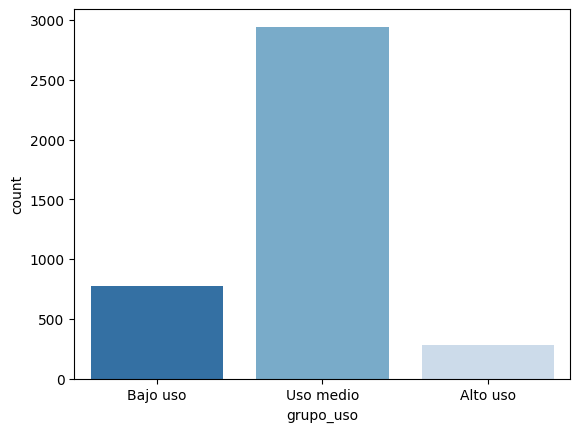

In [177]:
# Visualización de los segmentos por uso
sns.countplot(
    data=user_profile, 
    x="grupo_uso", 
    order=["Bajo uso", "Uso medio", "Alto uso"], 
    palette= "Blues_r",
             )

plt.show()

Text(0, 0.5, 'Cantidad de Usuarios')

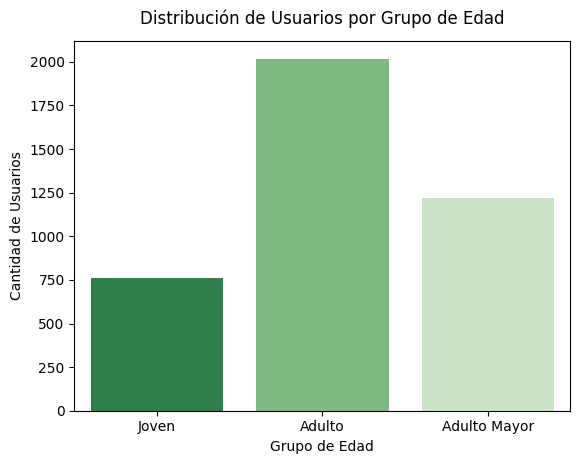

In [178]:
# Visualización de los segmentos por edad
sns.countplot(
    data=user_profile,
    x="grupo_edad",
    order=["Joven", "Adulto", "Adulto Mayor"],
    palette="Greens_r",
)

plt.title("Distribución de Usuarios por Grupo de Edad", fontsize=12, pad=12)
plt.xlabel("Grupo de Edad", fontsize=10)
plt.ylabel("Cantidad de Usuarios", fontsize=10)


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban? 


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**
Se identificaron 55 registros con valores negativos en `age`, representando un 1.3% del total. Además, se encontraron valores invalidos en las colummas de `duration` y `length` que fueron cambiados a "0"  para evitar sesgos en el análisis ya que no  eran valores faltantes si no que no aplicaban para ciertos casos.
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
Por Grupo de Uso:
Bajo uso (< 5 llamadas y < 5 mensajes): Constituye el volumen base de usuarios. Mantenimiento de consumo mínimo y llamadas breves.
Uso medio (< 10 llamadas y < 10 mensajes): Representa el segmento estándar de interacción equilibrada en consumo de voz y texto.
Alto uso (>= 10 en llamadas o mensajes): Representa el nicho de mayor tráfico (heavy users), con consumos acumulados de minutos significativamente superiores a la media.

Por Grupo de Edad:
Jóvenes (< 30 años): Muestran una mayor inclinación hacia el envío de mensajes respecto a la duración en llamadas de voz.
Adultos (30 a 59 años): Conforman el grupo demográfico más numeroso y estable, distribuidos de forma uniforme entre uso medio y alto.
Adultos Mayores (>= 60 años): Presentan hábitos orientados hacia las llamadas tradicionales de voz sobre la mensajería de texto.

¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
El segmento de 'Alto Uso' (especialmente en el rango de Adultos):
Son los clientes con mayor consumo de red y duración acumulada de minutos. Aunque representan un porcentaje menor de la base, son los de mayor valor de vida del cliente (CLV) y los candidatos principales para planes de suscripción de mayor margen o modalidad Unlimited.

¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
Usuarios que alcanzan hasta 17 mensajes, 15 llamadas o más de 150 minutos consumidos.
Comportamiento real, no errores: Indican que hay un grupo de clientes cuyas necesidades operativas superan con creces los límites de los planes estándar.

Riesgo de fuga (Churn): Si están en el plan Básico, estos usuarios podrían estar pagando sobrecostos o experimentando restricciones, lo que aumenta la probabilidad de que migren a la competencia si no se les ofrece un paquete adecuado.

¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes?
Crear un "Plan Ilimitado / Heavy User": Diseñar una oferta Premium enfocada en absorber a los usuarios con más de 60 minutos o 10 mensajes/llamadas, asegurando una tarifa plana competitiva que fidelice al segmento de alto valor.

Estrategia de Upgrade / Up-selling dirigida: Automatizar campañas para usuarios del plan Básico que sobrepasen el tope IQR (10.5 llamadas / 11.5 mensajes), invitándolos a migrar al plan Premium con un descuento inicial.
Plan Digital/Joven: Paquetes con prioridad en mensajes/datos móviles y menor cuota de minutos de voz tradicionales.

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Valores negativos en `age` (-999)
- Valores ausentes en `duration` y `length` debido a la clasificacion de call y texto.


🔍 **Segmentos por Edad**
- Jóvenes (< 30 años): Muestran una mayor inclinación hacia el envío de mensajes respecto a la duración en llamadas de voz.
- Adultos (30 a 59 años): Conforman el grupo demográfico más numeroso y estable, distribuidos de forma uniforme entre uso medio y alto.7
- Adultos Mayores (>= 60 años): Presentan hábitos orientados hacia las llamadas tradicionales de voz sobre la mensajería de texto.


📊 **Segmentos por Nivel de Uso**
- Bajo uso (< 5 llamadas y < 5 mensajes): Constituye el volumen base de usuarios. Mantenimiento de consumo mínimo y llamadas breves.
- Uso medio (< 10 llamadas y < 10 mensajes): Representa el segmento estándar de interacción equilibrada en consumo de voz y texto.
- Alto uso (>= 10 en llamadas o mensajes): Representa el nicho de mayor tráfico (heavy users), con consumos acumulados de minutos significativamente superiores a la media.


➡️ Esto sugiere que ...


💡 **Recomendaciones**
- Plan Digital/Joven: Paquetes con prioridad en mensajes/datos móviles y menor cuota de minutos de voz tradicionales.


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`